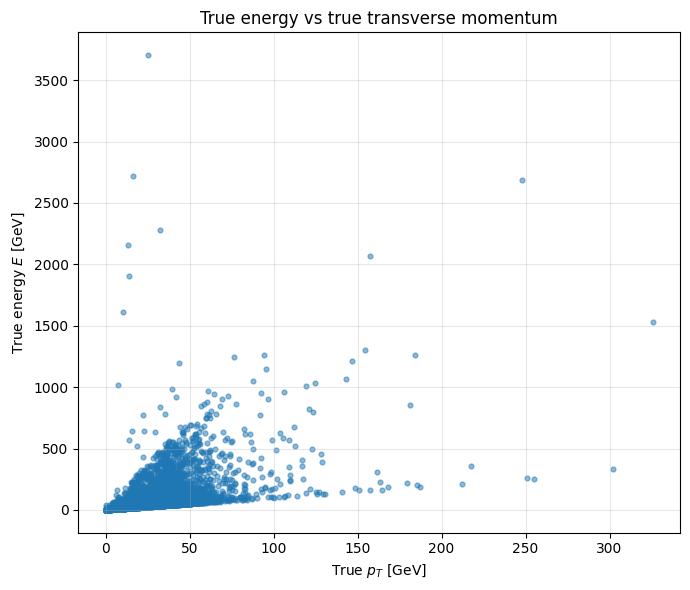

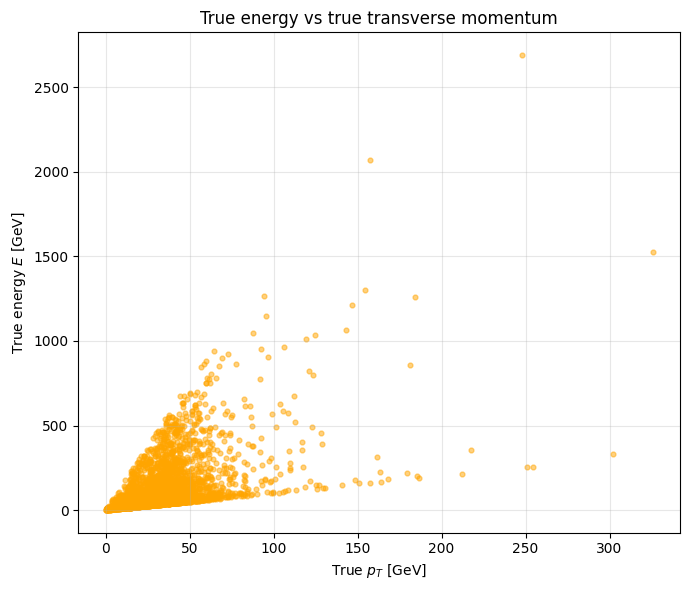

In [22]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Change this path to your actual parquet file
parquet_path = "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan.parquet"

df = pl.read_parquet(parquet_path)

truth_e = df["truth_energy"].to_numpy()
truth_px = df["truth_px"].to_numpy()
truth_py = df["truth_py"].to_numpy()

truth_pt = np.sqrt(truth_px**2 + truth_py**2)

plt.figure(figsize=(7, 6))
plt.scatter(truth_pt, truth_e, s=12, alpha=0.5)

plt.xlabel("True $p_T$ [GeV]")
plt.ylabel("True energy $E$ [GeV]")
plt.title("True energy vs true transverse momentum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Change this path to your actual parquet file
parquet_path = "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons.parquet"

df = pl.read_parquet(parquet_path)

truth_e = df["truth_energy"].to_numpy()
truth_px = df["truth_px"].to_numpy()
truth_py = df["truth_py"].to_numpy()

truth_pt = np.sqrt(truth_px**2 + truth_py**2)

plt.figure(figsize=(7, 6))
plt.scatter(truth_pt, truth_e, s=12, alpha=0.5, color = "orange")

plt.xlabel("True $p_T$ [GeV]")
plt.ylabel("True energy $E$ [GeV]")
plt.title("True energy vs true transverse momentum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

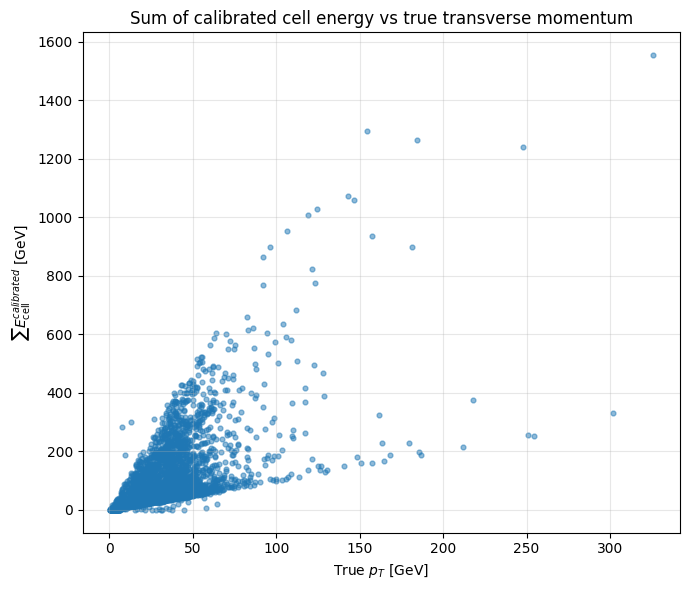

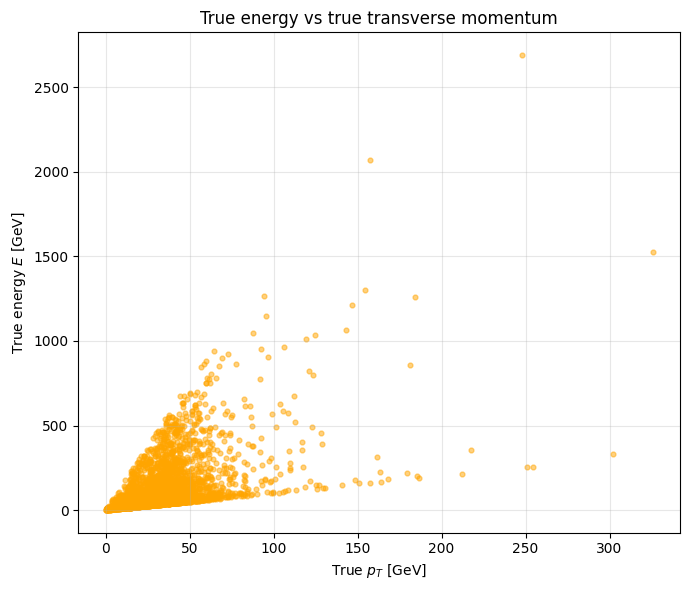

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

parquet_path = "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons.parquet"

df = pl.read_parquet(parquet_path)

truth_px = df["truth_px"].to_numpy()
truth_py = df["truth_py"].to_numpy()

truth_pt = np.sqrt(truth_px**2 + truth_py**2)

sum_cell_e_calibrated = df["cell_e_calibrated"].list.sum().to_numpy()

plt.figure(figsize=(7, 6))
plt.scatter(truth_pt, sum_cell_e_calibrated, s=12, alpha=0.5)

plt.xlabel("True $p_T$ [GeV]")
plt.ylabel(r"$\sum E_\mathrm{cell}^{calibrated}$ [GeV]")
plt.title("Sum of calibrated cell energy vs true transverse momentum")
plt.grid(True, alpha=0.3)
plt.tight_layout()

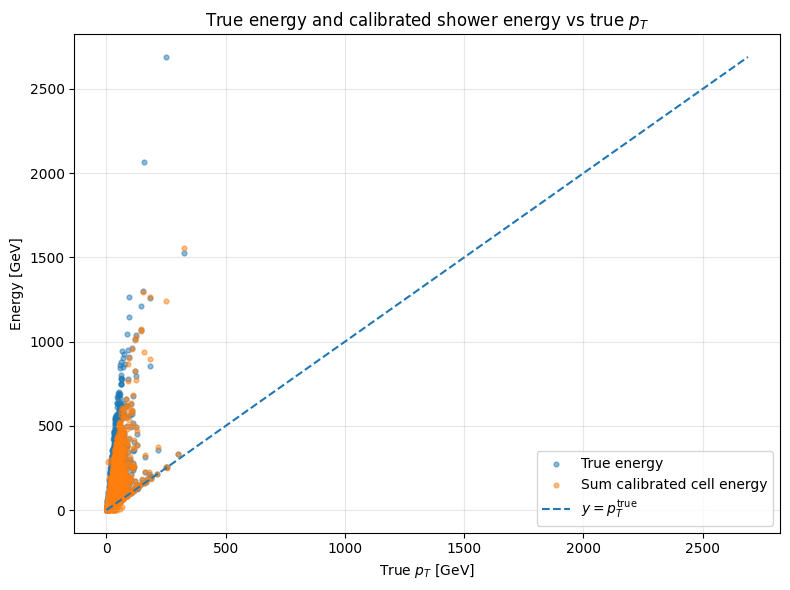

In [3]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

parquet_path = "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons.parquet"
df = pl.read_parquet(parquet_path)

truth_px = df["truth_px"].to_numpy()
truth_py = df["truth_py"].to_numpy()

truth_pt = np.sqrt(truth_px**2 + truth_py**2)
truth_e = df["truth_energy"].to_numpy()

sum_cell_e_calibrated = df["cell_e_calibrated"].list.sum().to_numpy()

plt.figure(figsize=(8, 6))

plt.scatter(
    truth_pt,
    truth_e,
    s=12,
    alpha=0.5,
    label="True energy"
)

plt.scatter(
    truth_pt,
    sum_cell_e_calibrated,
    s=12,
    alpha=0.5,
    label="Sum calibrated cell energy"
)

max_val = max(
    truth_pt.max(),
    truth_e.max(),
    sum_cell_e_calibrated.max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    label=r"$y = p_T^\mathrm{true}$"
)

plt.xlabel("True $p_T$ [GeV]")
plt.ylabel("Energy [GeV]")
plt.title("True energy and calibrated shower energy vs true $p_T$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

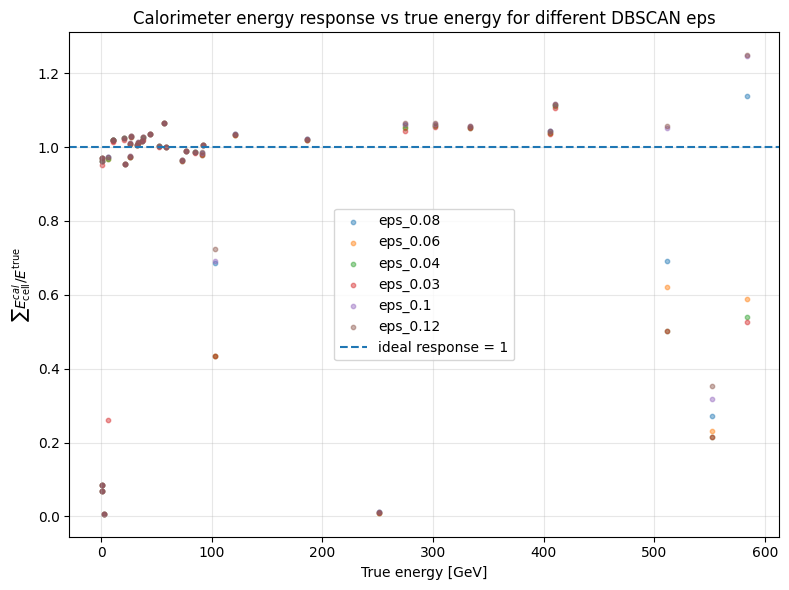

In [15]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

paths = {
    "eps_0.08": "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke.parquet",
    "eps_0.06": "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke2.parquet",
    "eps_0.04": "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke3.parquet",
    "eps_0.03": "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke4.parquet",
    "eps_0.1": "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke5.parquet",
    "eps_0.12": "/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke6.parquet",
}

plt.figure(figsize=(8, 6))

for label, path in paths.items():
    df = pl.read_parquet(path)

    truth_e = df["truth_energy"].to_numpy()
    e_obs = df["cell_e_calibrated"].list.sum().to_numpy()

    response = e_obs / truth_e

    plt.scatter(
        truth_e,
        response,
        s=10,
        alpha=0.45,
        label=label,
    )

plt.axhline(1.0, linestyle="--", label="ideal response = 1")

plt.xlabel("True energy [GeV]")
plt.ylabel(r"$\sum E_\mathrm{cell}^{cal} / E^\mathrm{true}$")
plt.title("Calorimeter energy response vs true energy for different DBSCAN eps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import polars as pl

for label, path in paths.items():
    df = pl.read_parquet(path)

    truth_e = df["truth_energy"].to_numpy()
    e_obs = df["cell_e_calibrated"].list.sum().to_numpy()
    n_cells = df["cell_e_calibrated"].list.len().to_numpy()

    response = e_obs / truth_e

    print("\n" + "=" * 40)
    print(label)
    print("=" * 40)
    print("number of electrons:", len(df))
    print("median response:", np.median(response))
    print("mean response:", response.mean())
    print("std response:", response.std())
    print("min response:", response.min())
    print("max response:", response.max())
    print("fraction response < 0.8:", np.mean(response < 0.8))
    print("fraction response > 1.2:", np.mean(response > 1.2))
    print("mean n_cells:", n_cells.mean())
    print("max n_cells:", n_cells.max())


eps_0.08
number of electrons: 38
median response: 1.0051092005344409
mean response: 0.8783646912402134
std response: 0.3200524516475457
min response: 0.0071129467712657225
max response: 1.138186823688174
fraction response < 0.8: 0.18421052631578946
fraction response > 1.2: 0.0
mean n_cells: 1281.7631578947369
max n_cells: 4652

eps_0.06
number of electrons: 38
median response: 1.003573427178204
mean response: 0.8536234733713501
std response: 0.3293255858827002
min response: 0.0071129467712657225
max response: 1.1139200516073382
fraction response < 0.8: 0.21052631578947367
fraction response > 1.2: 0.0
mean n_cells: 1238.657894736842
max n_cells: 4648

eps_0.04
number of electrons: 38
median response: 1.003431383098459
mean response: 0.8481453443652782
std response: 0.3336496018482066
min response: 0.0071129467712657225
max response: 1.1098018282955437
fraction response < 0.8: 0.21052631578947367
fraction response > 1.2: 0.0
mean n_cells: 1225.8157894736842
max n_cells: 4615

eps_0.03
n

In [ ]:

for name, path in paths.items():
    df = pl.read_parquet(path)

    truth_e = df["truth_energy"].to_numpy()
    e_obs = df["cell_e_calibrated"].list.sum().to_numpy()
    n_cells = df["cell_e_calibrated"].list.len().to_numpy()
    response = e_obs / truth_e

    print("\n" + "=" * 40)
    print(name)
    print("=" * 40)
    print("Number of electrons:", len(df))
    print("mean e_obs:", e_obs.mean())
    print("max e_obs:", e_obs.max())
    print("mean n_cells:", n_cells.mean())
    print("max n_cells:", n_cells.max())
    print("median response:", np.median(response))
    print("mean response:", response.mean())
    print("min response:", response.min())
    print("max response:", response.max())
    print("fraction response < 0.8:", np.mean(response < 0.8))
    print("fraction response > 1.2:", np.mean(response > 1.2))
    print("first 10 e_obs:", e_obs[:10])
    print("first 10 n_cells:", n_cells[:10])


eps_0.08
Number of electrons: 38
mean e_obs: 113.65411773772824
max e_obs: 664.1403479513247
mean n_cells: 1281.7631578947369
max n_cells: 4652
median response: 1.0051092005344409
mean response: 0.8783646912402134
min response: 0.0071129467712657225
max response: 1.138186823688174
fraction response < 0.8: 0.18421052631578946
fraction response > 1.2: 0.0
first 10 e_obs: [ 32.43432833  92.79385424 189.59862581 291.48457776  38.80954869
  60.76158763 353.24283416  45.62535445  70.23286676  11.17284471]
first 10 n_cells: [ 821 1762 2838 3610  965 1248  452 1155 1337  333]

eps_0.06
Number of electrons: 38
mean e_obs: 102.86954976227686
max e_obs: 456.9039112657774
mean n_cells: 1238.657894736842
max n_cells: 4648
median response: 1.003573427178204
mean response: 0.8536234733713501
min response: 0.0071129467712657225
max response: 1.1139200516073382
fraction response < 0.8: 0.21052631578947367
fraction response > 1.2: 0.0
first 10 e_obs: [ 32.43432833  92.77824042 189.56084612 289.93344951

In [11]:
for name, path in paths.items():
    print(name, "->", path)

eps_0.06 -> /Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke.parquet
eps_0.04 -> /Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke2.parquet
eps_0.03 -> /Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke3.parquet
eps_0.12 -> /Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons_dbscan_smoke4.parquet


In [14]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

for name, path in paths.items():
    print(name, file_hash(path))

eps_0.08 e1973d0bfd1dcb018fc5343763502ffb
eps_0.06 cf1cb8cf336a03e57331da7c404596a1
eps_0.04 e1973d0bfd1dcb018fc5343763502ffb
eps_0.03 bff26e652ac493795bf82b7a0d1d1d8b


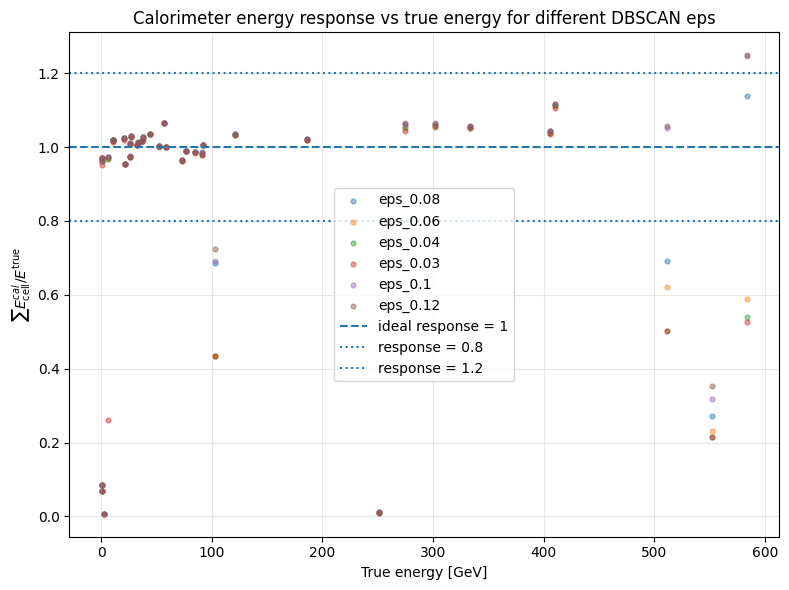

In [17]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for label, path in paths.items():
    df = pl.read_parquet(path)

    truth_e = df["truth_energy"].to_numpy()
    e_obs = df["cell_e_calibrated"].list.sum().to_numpy()
    response = e_obs / truth_e

    plt.scatter(
        truth_e,
        response,
        s=12,
        alpha=0.45,
        label=label,
    )

plt.axhline(1.0, linestyle="--", label="ideal response = 1")
plt.axhline(0.8, linestyle=":", label="response = 0.8")
plt.axhline(1.2, linestyle=":", label="response = 1.2")

plt.xlabel("True energy [GeV]")
plt.ylabel(r"$\sum E_\mathrm{cell}^{cal} / E^\mathrm{true}$")
plt.title("Calorimeter energy response vs true energy for different DBSCAN eps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()